# Why we should expect our baseline scores to be bad
Here's an example of why periodic behaviour leads to bad linear regression fits

In [54]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import root_mean_squared_error as rmse

In [70]:
N = 10000
X = pd.DataFrame({'x': list(range(N))})
y=np.array([np.sin(16*np.pi*x/N) for x in range(N)])+np.array([np.cos(24*np.pi*x/N) for x in range(N)])

n_splits = 5
timeseries = TimeSeriesSplit(n_splits=n_splits)

X_train = dict()
X_test = dict()
y_train = dict()
y_test = dict()
for i, (train_idx, test_idx) in enumerate(timeseries.split(X)):
    X_train[i], X_test[i] = X.iloc[train_idx], X.iloc[test_idx]
    y_train[i], y_test[i] = y[train_idx], y[test_idx]


<Axes: xlabel='x'>

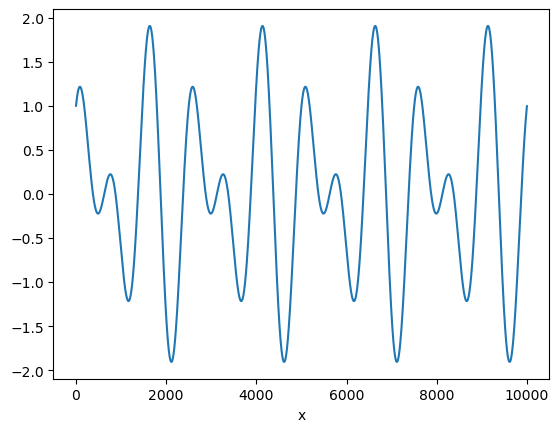

In [71]:
sns.lineplot(x=X['x'], y=y)

This data is clearly described by a function, with some very periodic looking behaviour.

In [72]:
categorical_columns = list(X.select_dtypes(include=str).columns)
numeric_columns = [x for x in X.columns if x not in categorical_columns]

one_hot_transformer = ColumnTransformer([
    ('datetime', StandardScaler(), numeric_columns)
], remainder='drop')

# List of models in order of flexibility.
models = {
    'dummy': DummyRegressor(strategy='mean'),
    'linear': Pipeline([ ('one hot encode', one_hot_transformer),
                         ('linreg', LinearRegression())]),
    'random_forest': Pipeline([ ('one hot encode', one_hot_transformer),
                         ('random_forest', RandomForestRegressor(
                             n_estimators=500, random_state=37, n_jobs=-1
                         ))
                                ])
}

In [73]:
score = dict()
for model in models.keys():
    for i in range(n_splits):
        models[model].fit(X_train[i], y_train[i])
        y_pred=models[model].predict(X_test[i])
        score[model,i]=rmse(y_test[i], y_pred)


for model in models.keys():
    score[model] = sum([score[model,i] for i in range(n_splits)])/n_splits
    print(f'For model {model}, the average RMSE is {score[model]}')

For model dummy, the average RMSE is 1.0276918058311462
For model linear, the average RMSE is 1.041754364761982
For model random_forest, the average RMSE is 1.546736225696351
